In [1]:
%pip install -U accelerate transformers datasets -q
%load_ext tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 800.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does n

In [2]:
from datasets import load_dataset
from transformers import pipeline
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, XLMRobertaForSequenceClassification, XLMRobertaTokenizer, DataCollatorWithPadding, EarlyStoppingCallback
from sklearn.metrics import f1_score, accuracy_score,  precision_score, recall_score, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
import pandas as pd
import numpy as np
import torch
import random
import seaborn as sns

**Step 1:** Load our dataset BRIGHTER and Pre-process our data

In [3]:
def load_and_preprocess_brighter(languages):

    all_languages_data = {}

    for lang in languages:
        dataset = load_dataset("brighter-dataset/BRIGHTER-emotion-categories", lang)
        print(f"{lang.upper()} dataset loaded with splits: {list(dataset.keys())}")

        def clean_split(split_ds):
            df = split_ds.to_pandas()
            df = df.dropna(subset=['text'])
            df = df[df['text'].str.strip() != '']
            return df

        cleaned_splits = {
            'train': clean_split(dataset['train']),
            'test': clean_split(dataset['test']),
            'dev': clean_split(dataset['dev'])
        }

        all_languages_data[lang] = cleaned_splits



    return all_languages_data

**Step 2:** Load our model - XLM Roberta

In [4]:
def load_model(label_columns, lang=None):
    tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

    model = XLMRobertaForSequenceClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=len(label_columns),
        problem_type="multi_label_classification"
    )

    return model, tokenizer

**Step 3:** Evaluate our model -> we our going to measure the performance of our model through metrics such as f1, precision and recall and then overall metrics such as macro_f1, micro_f1 and accuracy.  

In [5]:
def evaluate_model(model, tokenizer, test_data, label_columns):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    test_encodings = tokenizer(test_data["text"].tolist(), truncation=True, padding=True)
    test_dataset = EmotionDataset(test_encodings, test_data[label_columns].values)

    trainer = Trainer(model)
    raw_pred, _, _ = trainer.predict(test_dataset)

    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(raw_pred))
    preds = np.zeros(probs.shape)
    preds[np.where(probs >= 0.5)] = 1

    y_true = test_data[label_columns].values
    metrics = {}

    for i, emotion in enumerate(label_columns):
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true[:,i], preds[:,i], average='binary', zero_division=0
        )
        metrics[emotion] = {
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    metrics['overall'] = {
        'micro_f1': f1_score(y_true, preds, average='micro'),
        'macro_f1': f1_score(y_true, preds, average='macro'),
        'accuracy': accuracy_score(y_true, preds)
    }

    return metrics

In [6]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

**Step 4:** Check the zero-shot performance of our model by load the model and performing now fine tuning on it and rather instantly evaluating its performance.

In [7]:
def run_zero_shot(languages, label_columns,data):
    results = {}

    print("\n=== ZERO-SHOT EVALUATION ===")
    model, tokenizer = load_model(label_columns)
    zero_shot_metrics = evaluate_model(model, tokenizer, data["hau"]["test"], label_columns)
    results['zero_shot'] = zero_shot_metrics

    return results


**Steo 5:** Round 1 of simple finetuning our model and then training it on increasingly larger sample sizes of Hausa data and then evaluating its perfomance.

In [8]:
# round 1
# simple finetuning
def run_few_shot_and_gradual_round_1(languages, label_columns, data):
    results = {}

    print("\n=== ENGLISH-FINETUNED EVALUATION ===")
    model_eng, tokenizer = load_model(label_columns)

    eng_train = data["eng"]["train"]
    eng_encodings = tokenizer(eng_train["text"].tolist(), truncation=True, padding=True)
    eng_dataset = EmotionDataset(eng_encodings, eng_train[label_columns].values)

    eval_encodings = tokenizer(data["eng"]["dev"]["text"].tolist(), truncation=True, padding=True)
    eval_dataset = EmotionDataset(eval_encodings, data["eng"]["dev"][label_columns].values)

    data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding='longest',
    pad_to_multiple_of=8
    )

    callbacks=[EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.1  # FASTER PROCESSING -> Stop if improvement < 1%
    )]

    training_args = TrainingArguments(
        output_dir="./eng_finetuned",
        per_device_train_batch_size=16,
        num_train_epochs=5,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=3e-5,
        fp16=True,  # FASTER PROCESSING -> 1.5-2x speedup on modern GPUs
        fp16_full_eval=True,
        bf16=False,
        tf32=False,
        eval_accumulation_steps=1, # FASTER PROCESSING -> Faster evaluation
        report_to="none",
        logging_steps=50,
        disable_tqdm=False
      )

    trainer = Trainer(
        model=model_eng,
        args=training_args,
        train_dataset=eng_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator
    )


    try:
      trainer.train()
      print("\n=== TRAINING COMPLETED SUCCESSFULLY ===")
    except Exception as e:
      print(f"\n!!! TRAINING FAILED: {str(e)} !!!")

    eng_metrics = evaluate_model(model_eng, tokenizer, data["hau"]["test"], label_columns)
    results['eng_finetuned'] = eng_metrics

     # Gradually add Hausa data
    print("\n=== GRADUAL HAUSA FINE-TUNING ===")
    hausa_train = data["hau"]["train"]
    sample_sizes = [250, 1000, 3000]
    for size in sample_sizes:
        print(f"\n--- Evaluating with {size} Hausa samples ---")

        few_shot_train = hausa_train.groupby(label_columns, group_keys=False)\
                          .apply(lambda x: x.sample(min(len(x), size//len(label_columns))))

        # Start from English-finetuned model
        model_gradual, _ = load_model(label_columns)
        model_gradual.load_state_dict(model_eng.state_dict())  #

        # Fine-tune on Hausa samples
        train_encodings = tokenizer(few_shot_train["text"].tolist(), truncation=True, padding=True)
        train_dataset = EmotionDataset(train_encodings, few_shot_train[label_columns].values)

        trainer = Trainer(
            model=model_gradual,
            args=TrainingArguments(
                output_dir=f"./hausa_{size}",
                per_device_train_batch_size=4,
                num_train_epochs=10,
                eval_strategy="epoch",
                save_strategy="no",
                learning_rate=3e-5
            ),
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
        )

        trainer.train()
        metrics = evaluate_model(model_gradual, tokenizer, data["hau"]["test"], label_columns)
        results[f'hausa_{size}'] = metrics

    return results

**Steo 6:** Round 2 of more deeply finetuning our model and then once again training it on increasingly larger sample sizes of Hausa data and then evaluating its perfomance.

In [9]:
# round 2
# fine tune model even further
def run_few_shot_and_gradual_round_2(languages, label_columns, data):
    results = {}

    print("\n=== ENGLISH-FINETUNED EVALUATION ===")
    model_eng, tokenizer = load_model(label_columns)

    eng_train = data["eng"]["train"]
    eng_encodings = tokenizer(
        eng_train["text"].tolist(),
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    eng_dataset = EmotionDataset(eng_encodings, eng_train[label_columns].values)

    eval_encodings = tokenizer(
        data["eng"]["dev"]["text"].tolist(),
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    eval_dataset = EmotionDataset(eval_encodings, data["eng"]["dev"][label_columns].values)

    training_args = TrainingArguments(
      output_dir="./eng_finetuned",
      per_device_train_batch_size=16,  # MORE FINE TUNING -> Increased batch size
      num_train_epochs=5,
      eval_strategy="steps",
      eval_steps=500,
      save_strategy="steps",
      save_steps=500,
      save_total_limit=1,
      load_best_model_at_end=True,
      metric_for_best_model="eval_loss",
      greater_is_better=False,
      learning_rate=1e-5,
      lr_scheduler_type="cosine",  # MORE FINE TUNING ->  Learning rate scheduler
      warmup_steps=500,
      gradient_accumulation_steps=2,  # MORE FINE TUNING ->  Simulate larger batch size
      fp16=True,
      fp16_full_eval=True,
      bf16=False,
      tf32=False,
      eval_accumulation_steps=1,
      report_to="none",
      logging_steps=50,
      disable_tqdm=False
    )

    data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding='longest',
    pad_to_multiple_of=8
    )

    callbacks=[EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.1
    )]

    trainer = Trainer(
        model=model_eng,
        args=training_args,
        train_dataset=eng_dataset,
        eval_dataset=eval_dataset,
        callbacks=callbacks,
    )


    try:
      trainer.train()
      print("\n=== TRAINING COMPLETED SUCCESSFULLY ===")
    except Exception as e:
      print(f"\n!!! TRAINING FAILED: {str(e)} !!!")

    eng_metrics = evaluate_model(model_eng, tokenizer, data["hau"]["test"], label_columns)
    results['eng_finetuned'] = eng_metrics

    # MORE FINE TUNING -> Save the best English-finetuned model
    model_eng.save_pretrained("./eng_finetuned_best")
    tokenizer.save_pretrained("./eng_finetuned_best")

    print("\n=== GRADUAL HAUSA FINE-TUNING ===")
    hausa_train = data["hau"]["train"]
    sample_sizes = [250, 1000, 3000]
    for size in sample_sizes:
        print(f"\n--- Evaluating with {size} Hausa samples ---")

        few_shot_train = hausa_train.groupby(label_columns, group_keys=False)\
                     .apply(lambda x: x.sample(min(len(x), size//len(label_columns)), random_state=42))


        model_gradual, _ = load_model(label_columns)
        model_gradual = AutoModelForSequenceClassification.from_pretrained("./eng_finetuned_best")

        train_encodings = tokenizer(few_shot_train["text"].tolist(), truncation=True, padding=True)
        train_dataset = EmotionDataset(train_encodings, few_shot_train[label_columns].values)

        trainer = Trainer(
            model=model_gradual,
            args=TrainingArguments(
                output_dir=f"./hausa_{size}",
                per_device_train_batch_size=4,
                num_train_epochs=12,
                eval_strategy="epoch",
                save_strategy="no",
                learning_rate=1e-5,
                warmup_steps=500,
            ),
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,

        )

        trainer.train()
        metrics = evaluate_model(model_gradual, tokenizer, data["hau"]["test"], label_columns)
        results[f'hausa_{size}'] = metrics

    return results

**Steo 7:** Round 3 of still deeply finetuning our model but then training it on increasingly larger sample sizes of Hausa data AND english data and then evaluating its perfomance.

In [14]:
# round 3
# fine tune model further by training with more ENGLISH and HAUSA data combined
def run_few_shot_and_gradual_round_3(languages, label_columns, data):
    results = {}

    print("\n=== ENGLISH-FINETUNED EVALUATION ===")
    model_eng, tokenizer = load_model(label_columns)

    eng_train = data["eng"]["train"]
    eng_encodings = tokenizer(
        eng_train["text"].tolist(),
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    eng_dataset = EmotionDataset(eng_encodings, eng_train[label_columns].values)

    eval_encodings = tokenizer(
        data["eng"]["dev"]["text"].tolist(),
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    eval_dataset = EmotionDataset(eval_encodings, data["eng"]["dev"][label_columns].values)

    training_args = TrainingArguments(
      output_dir="./eng_finetuned",
      per_device_train_batch_size=16,  # MORE FINE TUNING -> Increased batch size
      num_train_epochs=5,
      eval_strategy="steps",
      eval_steps=500,
      save_strategy="steps",
      save_steps=500,
      save_total_limit=1,
      load_best_model_at_end=True,
      metric_for_best_model="eval_loss",
      greater_is_better=False,
      learning_rate=1e-5,
      lr_scheduler_type="cosine",  # MORE FINE TUNING ->  Learning rate scheduler
      warmup_steps=500,
      gradient_accumulation_steps=2,  # MORE FINE TUNING ->  Simulate larger batch size
      fp16=True,
      fp16_full_eval=True,
      bf16=False,
      tf32=False,
      eval_accumulation_steps=1,
      report_to="none",
      logging_steps=50,
      disable_tqdm=False
    )

    data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding='longest',
    pad_to_multiple_of=8
    )

    callbacks=[EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.1
    )]

    trainer = Trainer(
        model=model_eng,
        args=training_args,
        train_dataset=eng_dataset,
        eval_dataset=eval_dataset,
        callbacks=callbacks,
    )


    try:
      trainer.train()
      print("\n=== TRAINING COMPLETED SUCCESSFULLY ===")
    except Exception as e:
      print(f"\n!!! TRAINING FAILED: {str(e)} !!!")

    eng_metrics = evaluate_model(model_eng, tokenizer, data["hau"]["test"], label_columns)
    results['eng_finetuned'] = eng_metrics

    # MORE FINE TUNING -> Save the best English-finetuned model
    model_eng.save_pretrained("./eng_finetuned_best")
    tokenizer.save_pretrained("./eng_finetuned_best")

    print("\n=== GRADUAL HAUSA FINE-TUNING ===")
    hausa_train = data["hau"]["train"]
    sample_sizes = [250, 1000, 3000]
    for size in sample_sizes:
        print(f"\n--- Evaluating with {size} Hausa samples ---")

        few_shot_train = hausa_train.groupby(label_columns, group_keys=False)\
                     .apply(lambda x: x.sample(min(len(x), size//len(label_columns)), random_state=42))

        model_gradual, _ = load_model(label_columns)
        model_gradual = AutoModelForSequenceClassification.from_pretrained("./eng_finetuned_best")

        combined_train = pd.concat([eng_train, few_shot_train]).sample(frac=1).reset_index(drop=True)
        combined_encodings = tokenizer(combined_train["text"].tolist(), truncation=True, padding=True)
        combined_dataset = EmotionDataset(combined_encodings, combined_train[label_columns].values)

        trainer = Trainer(
            model=model_gradual,
            args=TrainingArguments(
                output_dir=f"./hausa_{size}",
                per_device_train_batch_size=2,
                num_train_epochs=5,
                eval_strategy="epoch",
                save_strategy="no",
                learning_rate=3e-5,
                weight_decay=0.01,
                warmup_ratio=0.1,
            ),
            train_dataset=combined_dataset,
            eval_dataset=eval_dataset,
        )

        trainer.train()
        metrics = evaluate_model(model_gradual, tokenizer, data["hau"]["test"], label_columns)
        results[f'hausa_{size}'] = metrics

    return results

**Results:** We will use plots to help us better view our results and compare performance between our methods.

In [11]:
def plot_metrics(results, title):

    overall_metrics = {
        approach: {
            'micro_f1': metrics["overall"]["micro_f1"],
            'macro_f1': metrics["overall"]["macro_f1"],
            'accuracy': metrics["overall"]["accuracy"]
        }
        for approach, metrics in results.items()
    }

    df = pd.DataFrame.from_dict(overall_metrics, orient='index')
    df = df.reset_index().melt(id_vars='index', var_name='metric', value_name='score')
    df.rename(columns={'index': 'approach'}, inplace=True)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df, x='approach', y='score', hue='metric',
                     palette=['skyblue', 'orange', 'green'])

    plt.title(f"Overall Metrics: {title}")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 10),
                   textcoords='offset points')

    plt.tight_layout()
    plt.show()

In [12]:
def plot_label_metrics(results, title):

    label_metrics = {}
    for approach, metrics in results.items():
        for label, scores in metrics.items():
            if label != 'overall':
                if label not in label_metrics:
                    label_metrics[label] = {}
                label_metrics[label][approach] = scores

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['precision', 'recall', 'f1']

    for i, metric in enumerate(metrics):

        data = {}
        for label, approaches in label_metrics.items():
            data[label] = {approach: scores[metric] for approach, scores in approaches.items()}

        df = pd.DataFrame.from_dict(data, orient='index')
        df.plot(kind='bar', ax=axes[i], rot=45)
        axes[i].set_title(metric.capitalize())
        axes[i].set_ylim(0, 1)
        axes[i].legend(title='Approach')

        for p in axes[i].patches:
            axes[i].annotate(f"{p.get_height():.2f}",
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', xytext=(0, 10),
                           textcoords='offset points')

    plt.suptitle(f"Label Metrics: {title}")
    plt.tight_layout()
    plt.show()

## Test it out

**1. Run the zero shot experiment**


*   Note you will need an API key from this website: wandb.ai and add that in when requested

*   Also note, this may take long to run even with setting the runtime type to T4 GPU



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/185k [00:00<?, ?B/s]

dev-00000-of-00001.parquet:   0%|          | 0.00/12.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/371k [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: u22621522 (u22621522-university-of-pretoria) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



ZERO_SHOT PERFORMANCE:
          precision   recall        f1
joy        0.150000  1.00000  0.260870
anger      0.000000  0.00000  0.000000
sadness    0.300847  0.64939  0.411197
surprise   0.163889  1.00000  0.281623
fear       0.156481  1.00000  0.270616

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.288804  0.244861       0.0


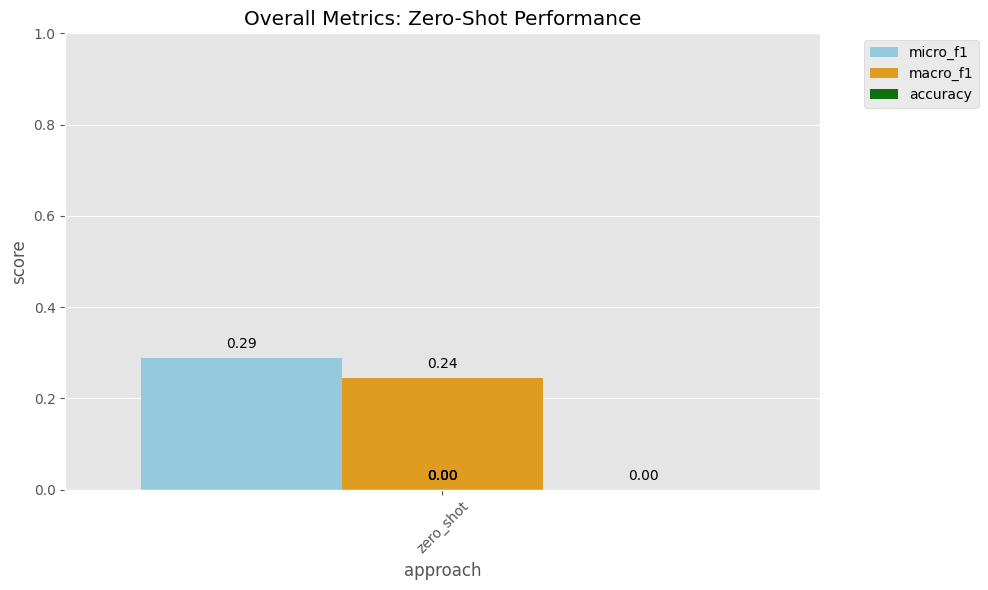

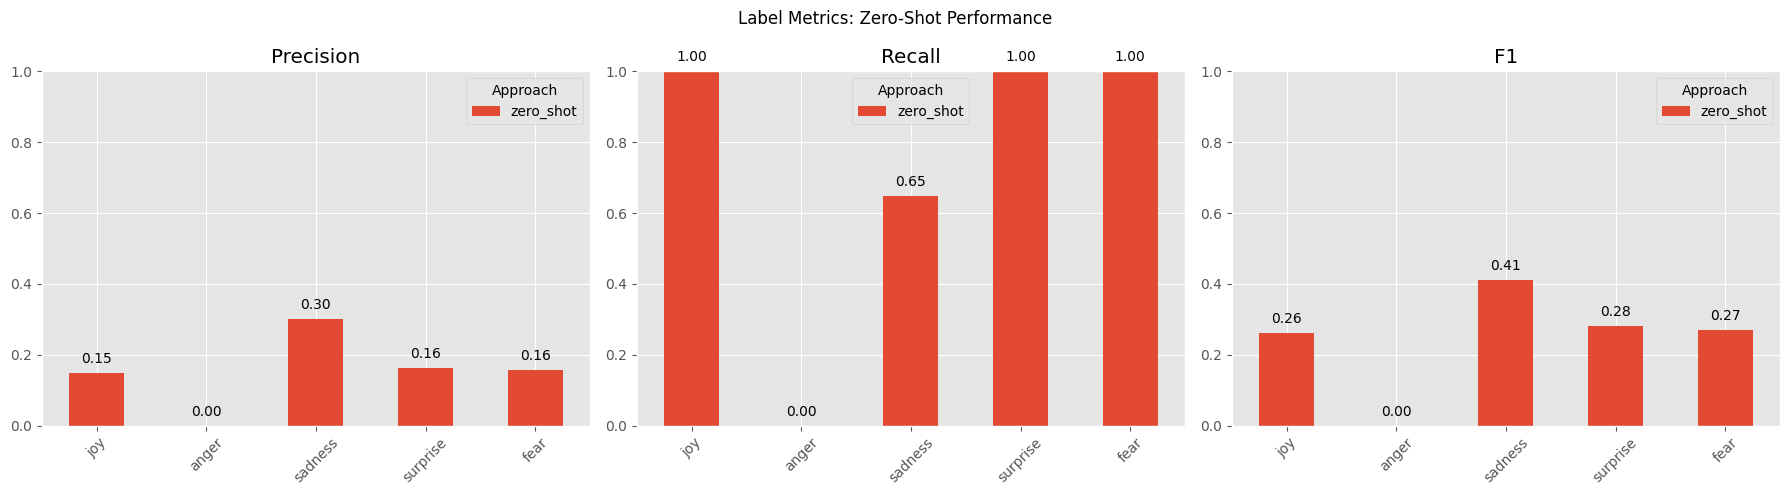

In [ ]:
# zero shot
label_columns = ["joy", "anger", "sadness", "surprise", "fear"]
model_name = "xlm-roberta-base"
languages=["eng", "hau"]
data = load_and_preprocess_brighter(languages)
base_model_name = "xlm-roberta-base"

# ZERO SHOT RESULTS -------------------------------------------------------------------

results_zero_shot = run_zero_shot(languages, label_columns, data)

for approach, metrics in results_zero_shot.items():
    print(f"\n{approach.upper()} PERFORMANCE:")

    label_metrics = {k: v for k, v in metrics.items() if k != "overall"}
    print(pd.DataFrame(label_metrics).transpose())

    print("\nOVERALL METRICS:")
    print(pd.DataFrame(metrics["overall"], index=["overall"]))

# Add plots
plot_metrics(results_zero_shot, "Zero-Shot Performance")
plot_label_metrics(results_zero_shot, "Zero-Shot Performance")


**1. Run the few shot experiment - round 1**


*   Note you will need an API key from this website: wandb.ai and add that in when requested

*   Also note, this may take long to run even with setting the runtime type to T4 GPU



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/185k [00:00<?, ?B/s]

dev-00000-of-00001.parquet:   0%|          | 0.00/12.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/371k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,No log,0.707003
2,0.473200,0.751928
3,0.378800,0.607792
4,0.314800,0.817319
5,0.314800,0.718640
6,0.243100,0.805896
7,0.194600,0.901268
8,0.146200,0.887933
9,0.146200,0.922623
10,0.115200,0.946892



--- Evaluating with 3000 Hausa samples ---


<ipython-input-8-3822610950>:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), size//len(label_columns))))
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.453100,0.703733
2,0.410800,0.702288
3,0.372000,0.680450
4,0.328400,0.734691
5,0.286600,0.726388
6,0.271800,0.808640
7,0.227200,0.775878
8,0.202300,0.837015
9,0.174100,0.861110
10,0.157100,0.869393



ENG_FINETUNED PERFORMANCE:
          precision    recall        f1
joy        0.185759  0.370370  0.247423
anger      0.259398  0.330144  0.290526
sadness    0.458716  0.304878  0.366300
surprise   0.179083  0.706215  0.285714
fear       0.154472  0.562130  0.242347

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.283728  0.286462  0.075926

HAUSA_250 PERFORMANCE:
          precision    recall        f1
joy        0.322581  0.246914  0.279720
anger      0.401434  0.535885  0.459016
sadness    0.563131  0.679878  0.616022
surprise   0.397260  0.491525  0.439394
fear       0.558140  0.710059  0.625000

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.510975  0.483831  0.335185

HAUSA_1000 PERFORMANCE:
          precision    recall        f1
joy        0.508475  0.555556  0.530973
anger      0.559633  0.583732  0.571429
sadness    0.597183  0.646341  0.620791
surprise   0.487179  0.536723  0.510753
fear       0.652174  0.710059  0.679887

OVERALL METRIC

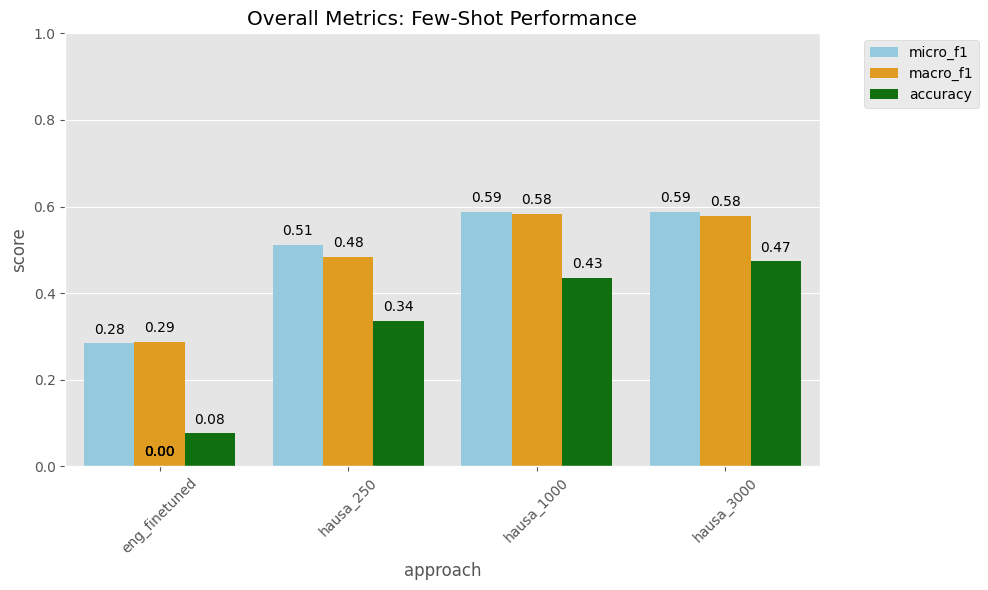

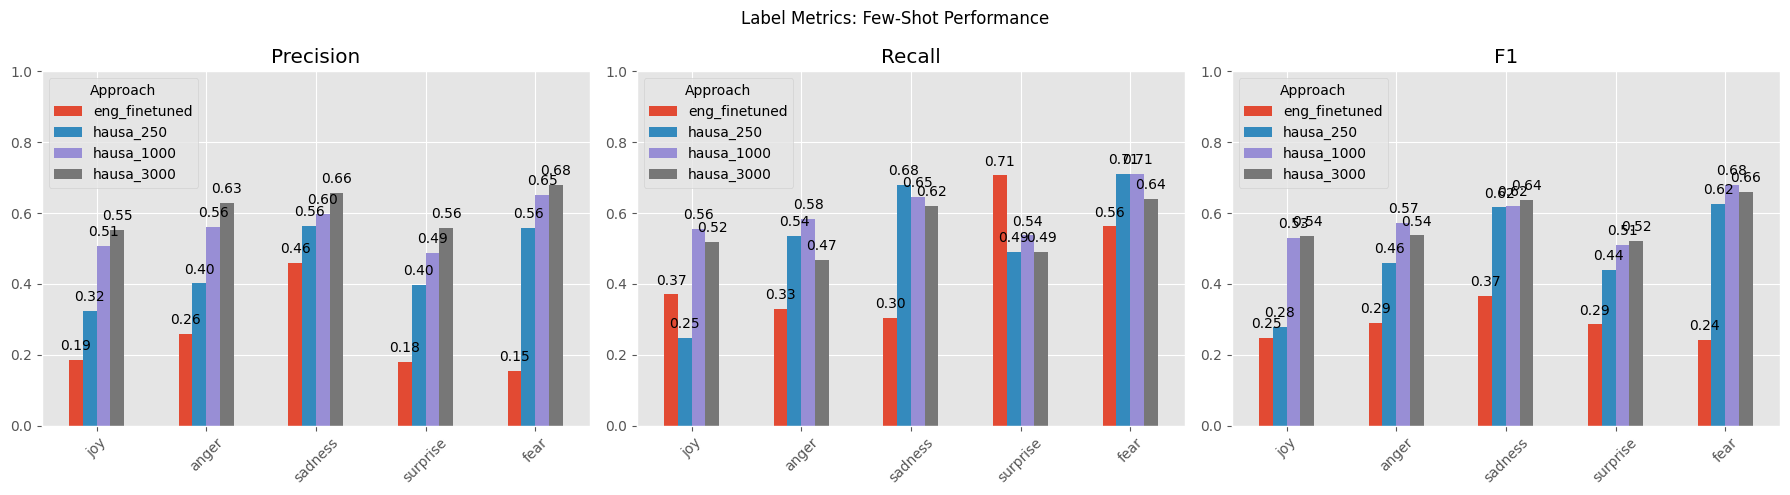

In [ ]:
# round 1
label_columns = ["joy", "anger", "sadness", "surprise", "fear"]
model_name = "xlm-roberta-base"
languages=["eng", "hau"]
data = load_and_preprocess_brighter(languages)
base_model_name = "xlm-roberta-base"

# FEW SHOT RESULTS -------------------------------------------------------------------

results_few_shot_and_gradual = run_few_shot_and_gradual_round_1(languages, label_columns, data)

for approach, metrics in results_few_shot_and_gradual.items():
    print(f"\n{approach.upper()} PERFORMANCE:")

    label_metrics = {k: v for k, v in metrics.items() if k != "overall"}
    print(pd.DataFrame(label_metrics).transpose())

    print("\nOVERALL METRICS:")
    print(pd.DataFrame(metrics["overall"], index=["overall"]))

# Add plots
plot_metrics(results_few_shot_and_gradual, "Few-Shot Performance")
plot_label_metrics(results_few_shot_and_gradual, "Few-Shot Performance")




**1. Run the few shot experiment - round 2**

*   Note you will need an API key from this website: wandb.ai and add that in when requested

*   Also note, this may take long to run even with setting the runtime type to T4 GPU



ENG dataset loaded with splits: ['train', 'dev', 'test']
HAU dataset loaded with splits: ['train', 'dev', 'test']

=== ENGLISH-FINETUNED EVALUATION ===


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss



=== TRAINING COMPLETED SUCCESSFULLY ===



=== GRADUAL HAUSA FINE-TUNING ===

--- Evaluating with 250 Hausa samples ---


...


--- Evaluating with 3000 Hausa samples ---


<ipython-input-25-2252598745>:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), size//len(label_columns)), random_state=42))
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.483000,0.611687
2,0.408900,0.682027
3,0.358700,0.632939
4,0.320800,0.636291
5,0.281600,0.687048


Epoch,Training Loss,Validation Loss
1,0.483000,0.611687
2,0.408900,0.682027
3,0.358700,0.632939
4,0.320800,0.636291
5,0.281600,0.687048
6,0.259500,0.718088
7,0.233200,0.724570
8,0.220500,0.740011
9,0.191700,0.751117
10,0.176800,0.794082



ENG_FINETUNED PERFORMANCE:
          precision    recall        f1
joy        0.176259  0.302469  0.222727
anger      0.000000  0.000000  0.000000
sadness    0.605263  0.070122  0.125683
surprise   0.207650  0.214689  0.211111
fear       0.176238  0.526627  0.264095

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.194241  0.164723  0.156481

HAUSA_250 PERFORMANCE:
          precision    recall        f1
joy        0.375661  0.438272  0.404558
anger      0.485149  0.468900  0.476886
sadness    0.546099  0.704268  0.615180
surprise   0.384181  0.384181  0.384181
fear       0.445545  0.798817  0.572034

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.515605  0.490568  0.294444

HAUSA_1000 PERFORMANCE:
          precision    recall        f1
joy        0.505495  0.567901  0.534884
anger      0.534091  0.449761  0.488312
sadness    0.590659  0.655488  0.621387
surprise   0.512346  0.468927  0.489676
fear       0.625616  0.751479  0.682796

OVERALL METRIC

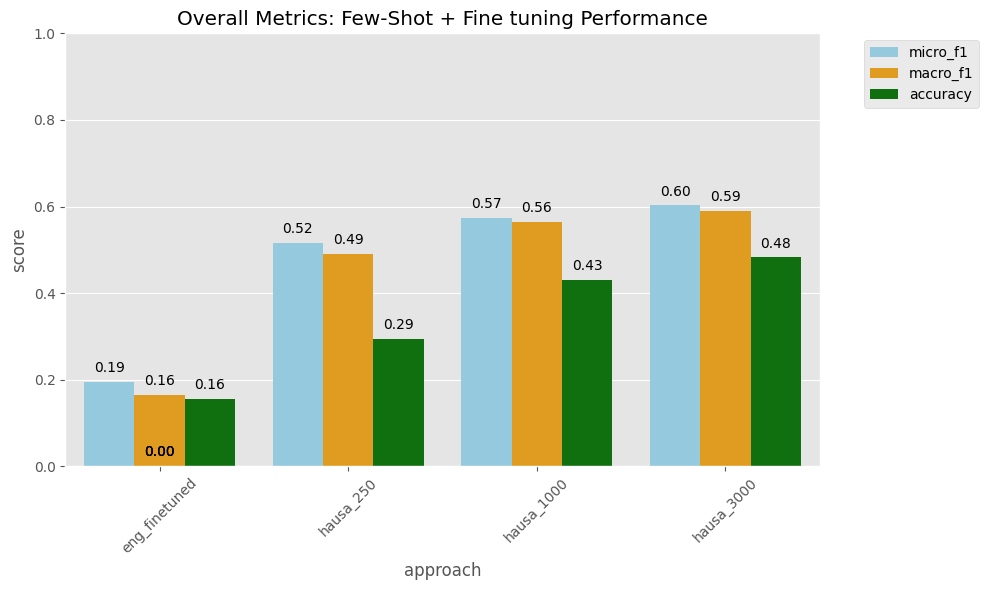

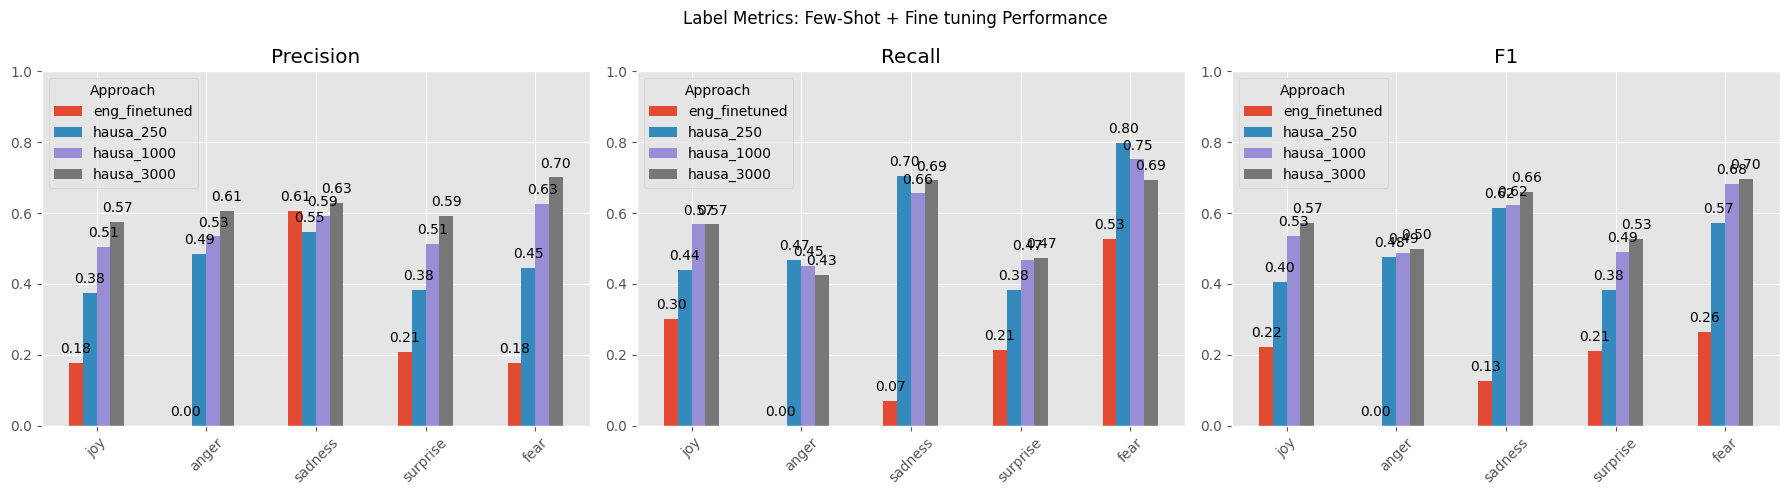

In [ ]:
# round 2
label_columns = ["joy", "anger", "sadness", "surprise", "fear"]
model_name = "xlm-roberta-base"
languages=["eng", "hau"]
data = load_and_preprocess_brighter(languages)
base_model_name = "xlm-roberta-base"

# FEW SHOT RESULTS -------------------------------------------------------------------

results_few_shot_and_gradual_with_fine_tuning = run_few_shot_and_gradual_round_2(languages, label_columns, data)

for approach, metrics in results_few_shot_and_gradual_with_fine_tuning.items():
    print(f"\n{approach.upper()} PERFORMANCE:")

    label_metrics = {k: v for k, v in metrics.items() if k != "overall"}
    print(pd.DataFrame(label_metrics).transpose())

    print("\nOVERALL METRICS:")
    print(pd.DataFrame(metrics["overall"], index=["overall"]))

# Add plots
plot_metrics(results_few_shot_and_gradual_with_fine_tuning, "Few-Shot + Fine tuning Performance")
plot_label_metrics(results_few_shot_and_gradual_with_fine_tuning,  "Few-Shot + Fine tuning Performance")

**1. Run the few shot experiment - round 3**


*   Note you will need an API key from this website: wandb.ai and add that in when requested

*   Also note, this may take long to run even with setting the runtime type to T4 GPU



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/185k [00:00<?, ?B/s]

dev-00000-of-00001.parquet:   0%|          | 0.00/12.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/371k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.467300,0.522596
2,0.412200,0.453182
3,0.325000,0.629739
4,0.257400,0.663517
5,0.188900,0.671486



--- Evaluating with 3000 Hausa samples ---


<ipython-input-10-3914547000>:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), size//len(label_columns))))
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.493400,0.534843
2,0.409700,0.465335
3,0.311100,0.527910
4,0.245400,0.612433
5,0.178000,0.628265



ENG_FINETUNED PERFORMANCE:
          precision    recall        f1
joy        0.237113  0.141975  0.177606
anger      0.310559  0.239234  0.270270
sadness    0.516484  0.286585  0.368627
surprise   0.193211  0.836158  0.313892
fear       0.159664  0.562130  0.248691

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.288124  0.275817  0.099074

HAUSA_250 PERFORMANCE:
          precision    recall        f1
joy        0.325153  0.327160  0.326154
anger      0.453271  0.464115  0.458629
sadness    0.536524  0.649390  0.587586
surprise   0.364865  0.457627  0.406015
fear       0.504902  0.609467  0.552279

OVERALL METRICS:
         micro_f1  macro_f1  accuracy
overall  0.487305  0.466133  0.310185

HAUSA_1000 PERFORMANCE:
          precision    recall        f1
joy        0.492647  0.413580  0.449664
anger      0.551546  0.511962  0.531017
sadness    0.626113  0.643293  0.634586
surprise   0.534161  0.485876  0.508876
fear       0.601064  0.668639  0.633053

OVERALL METRIC

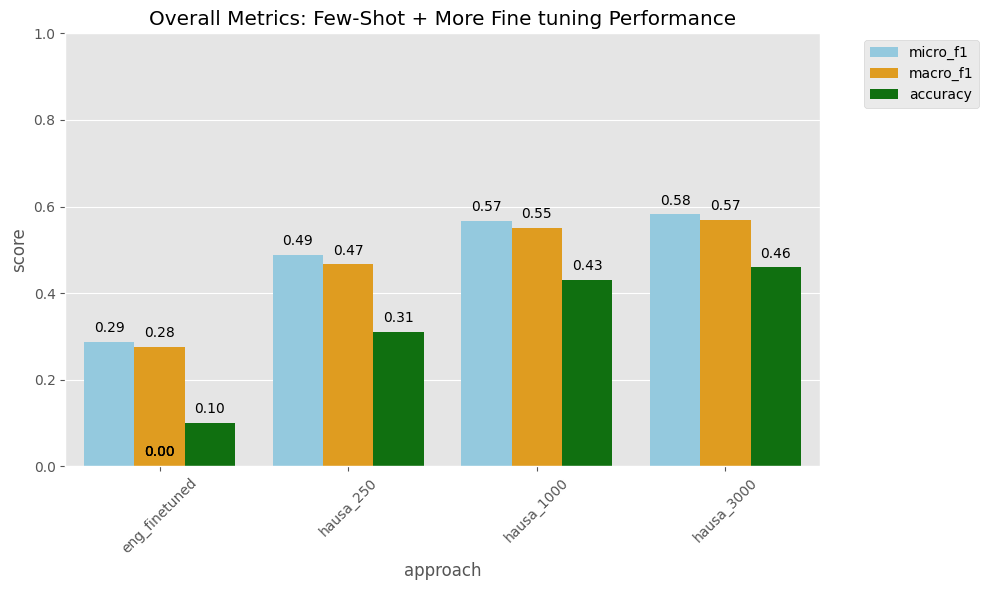

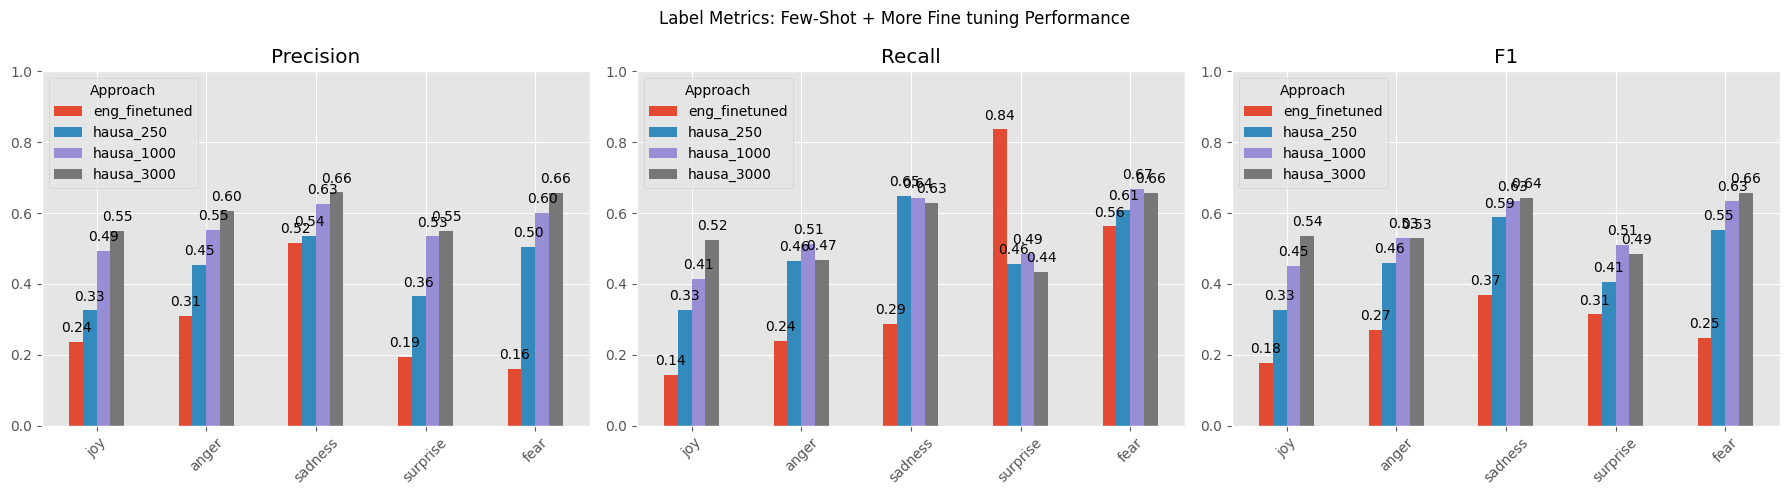

In [13]:
# round 3
label_columns = ["joy", "anger", "sadness", "surprise", "fear"]
model_name = "xlm-roberta-base"
languages=["eng", "hau"]
data = load_and_preprocess_brighter(languages)
base_model_name = "xlm-roberta-base"

# FEW SHOT RESULTS WITH GRADUAL HAUSA TRAINING----------------------------------------

results_few_shot_and_gradual_with_more_fine_tuning = run_few_shot_and_gradual_round_3(languages, label_columns, data)

for approach, metrics in results_few_shot_and_gradual_with_more_fine_tuning.items():
    print(f"\n{approach.upper()} PERFORMANCE:")

    label_metrics = {k: v for k, v in metrics.items() if k != "overall"}
    print(pd.DataFrame(label_metrics).transpose())

    print("\nOVERALL METRICS:")
    print(pd.DataFrame(metrics["overall"], index=["overall"]))


# Add plots
plot_metrics(results_few_shot_and_gradual_with_more_fine_tuning,  "Few-Shot + More Fine tuning Performance")
plot_label_metrics(results_few_shot_and_gradual_with_more_fine_tuning,  "Few-Shot + More Fine tuning Performance")
